In [186]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("/Users/AlanHDLR/Desktop")

In [188]:
drugs = pd.read_csv("drugs.csv")
drugs

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [190]:
# Columnas de referencia
feature_cols = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]
X = drugs[feature_cols].values
y = drugs.Drug

In [192]:
# Preprocesamiento para las variables categoricas
from sklearn import preprocessing

# Columna Sex
Cod_sex = preprocessing.LabelEncoder()
Cod_sex.fit(["F", "M"])
X[:,1] = Cod_sex.transform(X[:,1])

# Columna BP
Cod_bp = preprocessing.LabelEncoder()
Cod_bp.fit(["HIGH", "NORMAL", "LOW"])
X[:,2] = Cod_bp.transform(X[:,2])

# Columna Cholesterol
Cod_cholesterol = preprocessing.LabelEncoder()
Cod_cholesterol.fit(["HIGH", "NORMAL"])
X[:,3] = Cod_cholesterol.transform(X[:,3])

In [194]:
X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [196]:
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

In [198]:
# CReación de grupos de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

# Bosques aleatorios (Random Forest)

In [201]:
from sklearn.ensemble import RandomForestClassifier

In [203]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 1)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [205]:
# Score F1 para el grupo de entrenamiento (training)
rf.score(X_train, y_train)

1.0

In [207]:
# Score F1 para el grupo de entrenamiento (testing)
rf.score(X_test, y_test)

0.95

In [209]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      0.75      0.86         4
       drugX       0.95      1.00      0.97        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.95        60
   macro avg       0.92      0.88      0.89        60
weighted avg       0.96      0.95      0.95        60



In [211]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importance(drugs, model):
    n_features = feature_cols
    plt.barh(n_features, model.feature_importances_, align="center")
    plt.xlabel("Importancia de las variables")
    plt.ylabel("Caracteristicas")
    plt.show()

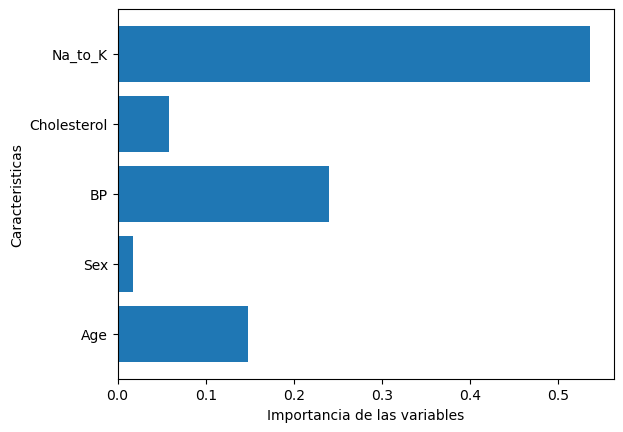

In [213]:
# Que tan importante fue cada variable para pornosticar el resultado
plot_feature_importance(drugs, rf)

# Gradient boosted trees

In [216]:
from sklearn.ensemble import GradientBoostingClassifier

In [218]:
# Creación de grupos de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [220]:
gbt = GradientBoostingClassifier(n_estimators = 100, random_state = 1) # 100 árboles de profundidad de 3 (Default)
gbt.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

In [222]:
# Score F1 para el grupo de entrenamiento
gbt.score(X_train, y_train)

1.0

In [224]:
# Score F1 para el grupo de prueba
gbt.score(X_test, y_test)

0.9666666666666667

In [226]:
# Estadisticas de desempeño
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



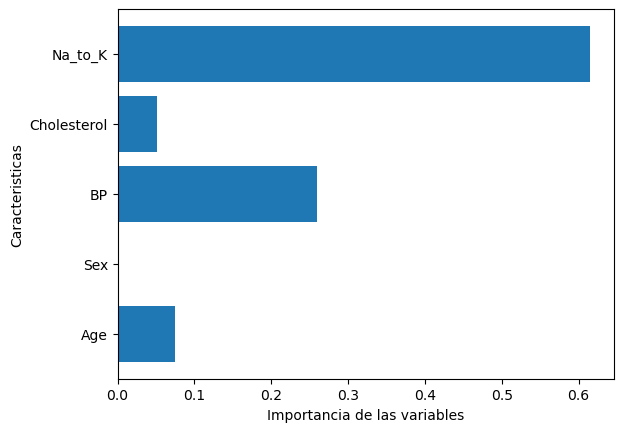

In [228]:
plot_feature_importance(drugs, gbt)

In [278]:
# Intento alternativco de Gradient Boosting
gbt = GradientBoostingClassifier(n_estimators = 100, random_state = 1, max_depth = 2) 
gbt.fit(X_train, y_train)
print("Training F1 Score: ,", gbt.score(X_train, y_train))
print("Testing F1 Score: ,", gbt.score(X_test, y_test))

Training F1 Score: , 1.0
Testing F1 Score: , 0.95


In [280]:
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.57      1.00      0.73         4
       drugB       1.00      0.50      0.67         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.95        60
   macro avg       0.91      0.90      0.88        60
weighted avg       0.97      0.95      0.95        60



In [282]:
# Intento alternativco de Gradient Boosting
gbt = GradientBoostingClassifier(n_estimators = 100, random_state = 1, max_depth = 4) 
gbt.fit(X_train, y_train)
print("Training F1 Score: ,", gbt.score(X_train, y_train))
print("Testing F1 Score: ,", gbt.score(X_test, y_test))

Training F1 Score: , 1.0
Testing F1 Score: , 0.95


In [284]:
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.50      0.67         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       0.96      1.00      0.98        27

    accuracy                           0.95        60
   macro avg       0.93      0.90      0.89        60
weighted avg       0.96      0.95      0.95        60



In [286]:
# Intento alternativco de Gradient Boosting
gbt = GradientBoostingClassifier(n_estimators = 100, random_state = 1, max_depth = 3) 
gbt.fit(X_train, y_train)
print("Training F1 Score: ,", gbt.score(X_train, y_train))
print("Testing F1 Score: ,", gbt.score(X_test, y_test))

Training F1 Score: , 1.0
Testing F1 Score: , 0.9666666666666667


In [288]:
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [290]:
# Intento alternativco de Gradient Boosting
gbt = GradientBoostingClassifier(n_estimators = 200, random_state = 1, max_depth = 3) 
gbt.fit(X_train, y_train)
print("Training F1 Score: ,", gbt.score(X_train, y_train))
print("Testing F1 Score: ,", gbt.score(X_test, y_test))

Training F1 Score: , 1.0
Testing F1 Score: , 0.9666666666666667


In [294]:
# Intento alternativco de Gradient Boosting
gbt = GradientBoostingClassifier(n_estimators = 200, random_state = 1, max_depth = 2) 
gbt.fit(X_train, y_train)
print("Training F1 Score: ,", gbt.score(X_train, y_train))
print("Testing F1 Score: ,", gbt.score(X_test, y_test))

Training F1 Score: , 1.0
Testing F1 Score: , 0.9666666666666667


In [296]:
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [ ]:
y_pred = gbt.predict(X_test)
print(classification_report(y_test, y_pred))

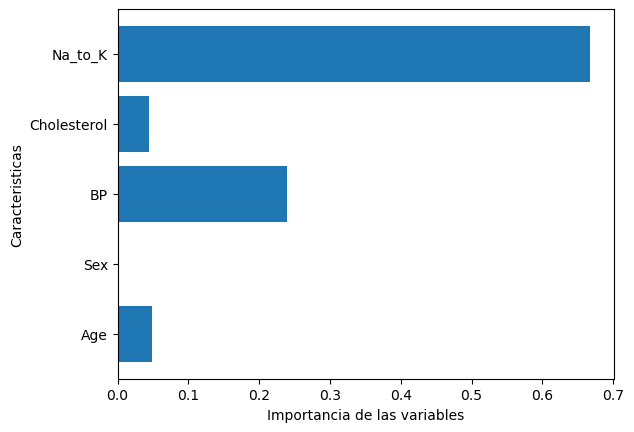

In [153]:
plot_feature_importance(drugs, gbt)

In [155]:
# Insertamos al nuevo paciente con los valores categoricos procesados
nuevo_paciente = {
    "Age": 50,
    "Sex": 0,
    "BP": 0,
    "Cholesterol": 1,
    "Na_to_K": 15.302
}

# Convertimos a DataFrame
df_paciente = pd.DataFrame([nuevo_paciente])

# Maquina Vectorial : "rbf"
prediccion = gbt.predict(df_paciente)
print("El medicamento recomendado es: " + prediccion)

['El medicamento recomendado es: drugY']


# AdaBoost Classifier

In [158]:
from sklearn.ensemble import AdaBoostClassifier

In [242]:
# Creación de grupos de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [244]:
# AdaBoost usa árboles de decisión como clasificador por Default
abc = AdaBoostClassifier(n_estimators = 50, learning_rate = 1)

# Entrenamiento del clasificador AdaBoost
model = abc.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [246]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.40      1.00      0.57         4
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.45      0.60      0.50        60
weighted avg       0.74      0.83      0.77        60



In [248]:
# Utilización de SVM como clasificador para AdaBoost
from sklearn.svm import SVC
svc = SVC(probability = True, kernel = "linear")

In [250]:
# Creación del objeto de clasificación AdaBoost
abc = AdaBoostClassifier(n_estimators = 50, estimator = svc, learning_rate = 1)

model = abc.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [252]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         4
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       1.00      0.11      0.19        19
       drugY       0.47      1.00      0.64        27

    accuracy                           0.48        60
   macro avg       0.29      0.22      0.17        60
weighted avg       0.53      0.48      0.35        60



In [172]:
# Insertamos al nuevo paciente con los valores categoricos procesados
nuevo_paciente = {
    "Age": 50,
    "Sex": 0,
    "BP": 0,
    "Cholesterol": 1,
    "Na_to_K": 15.302
}

# Convertimos a DataFrame
df_paciente = pd.DataFrame([nuevo_paciente])

# Maquina Vectorial : "rbf"
prediccion = abc.predict(df_paciente)
print("El medicamento recomendado es: " + prediccion)

['El medicamento recomendado es: drugY']
